# Pipeline 2: Donation-to-Outcome Impact Attribution
## Lighthouse Sanctuary — ML Pipeline Notebook

---

### Pipeline Thinking (Ch. 1 / Foreword)
This pipeline answers one of the most important questions for any fundraising organisation: *"Where does my money go, and does it actually make a difference?"* It connects donation allocations to measured resident outcomes at the safehouse level, and generates personalised impact statements for donor communications. The story runs from a business communication problem through correlational regression to a deployable statement-generation artifact.

---

### Prediction vs. Explanation (Ch. 9–11)
**This is an EXPLANATION pipeline — not a prediction pipeline.**

The goal is to *quantify and communicate* the relationship between donation allocations and measurable outcome improvements. We use **OLS regression (statsmodels)** because:
- Coefficients are the output, not predictions — we need their direction, magnitude, and uncertainty
- Confidence intervals bound the impact statements we generate for donors
- p-values gate which program areas get statements (weak signals stay silent)
- R² is expected to be low — safehouse outcomes are influenced by many factors beyond donations; what matters is whether the donation signal is detectable and statistically significant

**What this pipeline does NOT do:** It does not claim causation. Allocations and outcomes co-occur at the safehouse level. The statements generated say "associated with," not "caused."

**Success criteria:**
- ≥ 3 program areas produce statistically significant correlations (p < 0.05)
- Effect size ≥ small (Cohen's f² ≥ 0.02) before generating any statement
- Statement coverage ≥ 60% of active donors


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports OK")


All imports OK


## Phase 2 — Data Acquisition

In [2]:
# ── Load CSVs ────────────────────────────────────────────────────────────────
alloc   = pd.read_csv('./csvs/donation_allocations.csv', parse_dates=['allocation_date'])
metrics = pd.read_csv('./csvs/safehouse_monthly_metrics.csv',
                      parse_dates=['month_start','month_end'])
donations = pd.read_csv('./csvs/donations.csv', parse_dates=['donation_date'])
safehouses = pd.read_csv('./csvs/safehouses.csv')

print(f"Allocations:          {alloc.shape}")
print(f"Monthly metrics:      {metrics.shape}")
print(f"Donations:            {donations.shape}")
print(f"Safehouses:           {safehouses.shape}")

# Join allocations → supporter_id
alloc = alloc.merge(donations[['donation_id','supporter_id']], on='donation_id', how='left')
print(f"\nAllocations with supporter_id: {alloc['supporter_id'].notna().sum()}")
alloc.head(3)


Allocations:          (521, 7)
Monthly metrics:      (450, 11)
Donations:            (420, 13)
Safehouses:           (9, 13)

Allocations with supporter_id: 521


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes,supporter_id
0,1,1,2,Education,717.1800,2025-12-31,NaN,42
1,2,2,4,Transport,35.1500,2025-12-02,NaN,25
2,3,3,8,Wellbeing,1074.6500,2024-12-02,NaN,19


In [3]:
# ── Time-window join (pandas equivalent of the SQL LEFT JOIN on month offsets) ─
# For each allocation, find monthly metrics at allocation month,
# +3 months, and +6 months at the same safehouse.

alloc['alloc_month'] = alloc['allocation_date'].dt.to_period('M').dt.to_timestamp()

def get_metric(metrics_df, safehouse_id, month_ts, cols):
    """Retrieve specific metric columns for a given safehouse + month."""
    row = metrics_df[
        (metrics_df['safehouse_id'] == safehouse_id) &
        (metrics_df['month_start'] == month_ts)
    ]
    if row.empty:
        return {c: np.nan for c in cols}
    return {c: row.iloc[0].get(c, np.nan) for c in cols}

OUTCOME_COLS = ['avg_education_progress', 'avg_health_score',
                'process_recording_count', 'incident_count']

rows = []
for _, a in alloc.iterrows():
    m0  = a['alloc_month']
    m3  = m0 + pd.DateOffset(months=3)
    m6  = m0 + pd.DateOffset(months=6)
    sid = a['safehouse_id']

    base = get_metric(metrics, sid, m0, OUTCOME_COLS)
    out3 = get_metric(metrics, sid, m3, OUTCOME_COLS)
    out6 = get_metric(metrics, sid, m6, OUTCOME_COLS)

    row = {
        'allocation_id':    a['allocation_id'],
        'supporter_id':     a['supporter_id'],
        'safehouse_id':     sid,
        'program_area':     a['program_area'],
        'amount_allocated': a['amount_allocated'],
        'allocation_date':  a['allocation_date'],
        'alloc_month':      m0,
    }
    for c in OUTCOME_COLS:
        row[f'{c}_base'] = base[c]
        row[f'{c}_3m']   = out3[c]
        row[f'{c}_6m']   = out6[c]
    rows.append(row)

df = pd.DataFrame(rows)
df = df[df['amount_allocated'] > 0]
print(f"Base dataset: {df.shape}")
print(f"Rows with 3m edu data:    {df['avg_education_progress_3m'].notna().sum()}")
print(f"Rows with 3m health data: {df['avg_health_score_3m'].notna().sum()}")
df.head(3)


Base dataset: (521, 19)
Rows with 3m edu data:    376
Rows with 3m health data: 376


,allocation_id,supporter_id,safehouse_id,program_area,amount_allocated,allocation_date,alloc_month,avg_education_progress_base,avg_education_progress_3m,avg_education_progress_6m,avg_health_score_base,avg_health_score_3m,avg_health_score_6m,process_recording_count_base,process_recording_count_3m,process_recording_count_6m,incident_count_base,incident_count_3m,incident_count_6m
0,1,42,2,Education,717.1800,2025-12-31,2025-12-01,100.0000,NaN,NaN,3.0600,NaN,NaN,10,3,1,1,0,0
1,2,25,4,Transport,35.1500,2025-12-02,2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,16,0,0,2,0,0
2,3,19,8,Wellbeing,1074.6500,2024-12-02,2024-12-01,54.6000,74.2700,92.9000,3.1500,3.2200,3.4400,4,5,8,0,0,0


## Phase 3 — Exploratory Data Analysis (Ch. 6, 8)

In [4]:
# ── unistats helper ───────────────────────────────────────────────────────────
def unistats(df):
    rows = []
    for col in df.select_dtypes(include='number').columns:
        s = df[col].dropna()
        rows.append({'col': col, 'count': len(s), 'nulls': df[col].isna().sum(),
                     'mean': round(s.mean(),3), 'median': round(s.median(),3),
                     'std': round(s.std(),3), 'skew': round(s.skew(),2),
                     'min': round(s.min(),3), 'max': round(s.max(),3)})
    return pd.DataFrame(rows).set_index('col')

print("=== Allocation amounts ===")
print(unistats(df[['amount_allocated']]))
print("\n=== Outcome columns (baseline) ===")
base_cols = [c for c in df.columns if c.endswith('_base')]
print(unistats(df[base_cols]))


=== Allocation amounts ===
                  count  nulls     mean   median      std   skew    min  \
col                                                                       
amount_allocated    521      0 542.1040 412.9100 601.2900 3.3800 0.8100   

                       max  
col                         
amount_allocated 6481.5400  

=== Outcome columns (baseline) ===
                              count  nulls    mean  median     std    skew  \
col                                                                          
avg_education_progress_base     401    120 77.4900 79.0000 18.4600 -0.6900   
avg_health_score_base           401    120  3.1910  3.1700  0.2260 -0.5600   
process_recording_count_base    521      0  8.0120  7.0000  5.7800  0.6500   
incident_count_base             521      0  0.3210  0.0000  0.6000  2.0300   

                                 min      max  
col                                            
avg_education_progress_base  13.0000 100.0000  
avg_health_

In [5]:
# ── Compute outcome deltas ────────────────────────────────────────────────────
df['edu_delta_3m']    = df['avg_education_progress_3m']   - df['avg_education_progress_base']
df['health_delta_3m'] = df['avg_health_score_3m']         - df['avg_health_score_base']
df['edu_delta_6m']    = df['avg_education_progress_6m']   - df['avg_education_progress_base']
df['health_delta_6m'] = df['avg_health_score_6m']         - df['avg_health_score_base']

print("=== Outcome deltas (3-month window) ===")
print(unistats(df[['edu_delta_3m','health_delta_3m']]))
print("\n=== Delta by program area ===")
print(df.groupby('program_area')[['edu_delta_3m','health_delta_3m']].agg(['mean','count']).round(3))


=== Outcome deltas (3-month window) ===
                 count  nulls   mean  median     std    skew      min     max
col                                                                          
edu_delta_3m       342    179 6.6410  7.9800 18.2610 -0.5700 -57.5500 55.7500
health_delta_3m    342    179 0.0330  0.0600  0.1670 -0.3300  -0.3700  0.4200

=== Delta by program area ===
             edu_delta_3m       health_delta_3m      
                     mean count            mean count
program_area                                         
Education          7.2360    69          0.0360    69
Maintenance        3.8330    37          0.0450    37
Operations         7.6410    88          0.0420    88
Outreach           6.1530    31          0.0360    31
Transport         10.2550    47          0.0290    47
Wellbeing          4.0740    70          0.0130    70


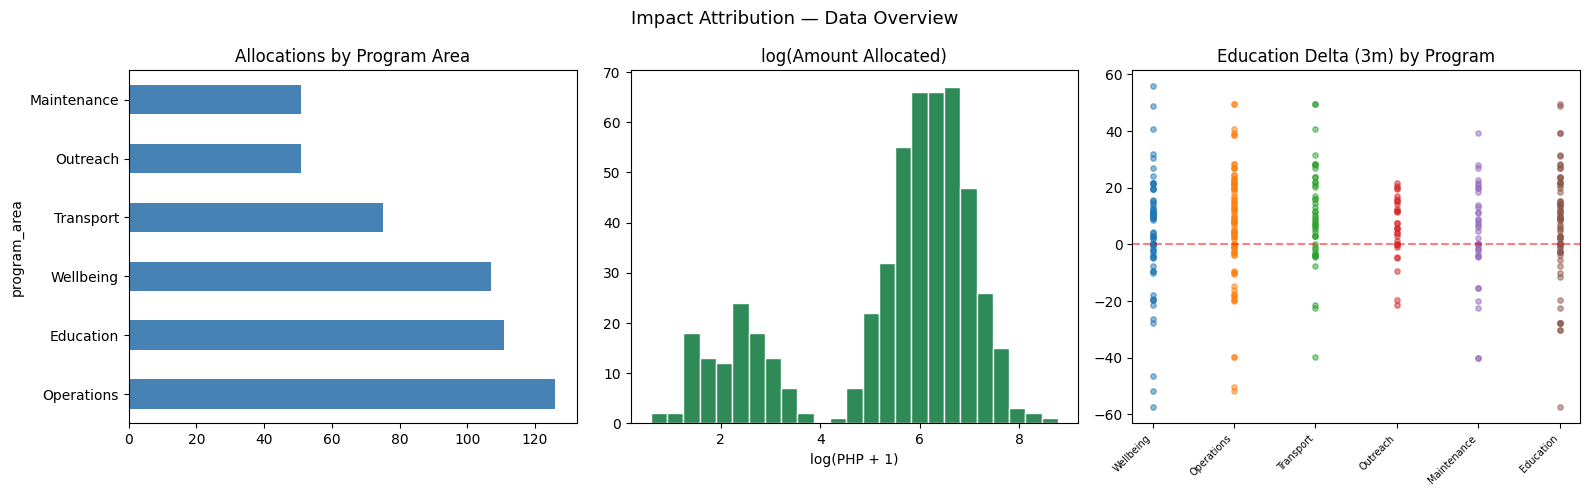

In [6]:
# ── Distribution of program areas and allocation amounts ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Impact Attribution — Data Overview', fontsize=13)

df['program_area'].value_counts().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Allocations by Program Area')

axes[1].hist(np.log1p(df['amount_allocated']), bins=25, color='seagreen', edgecolor='white')
axes[1].set_title('log(Amount Allocated)')
axes[1].set_xlabel('log(PHP + 1)')

delta_data = df[['program_area','edu_delta_3m']].dropna()
programs   = delta_data['program_area'].unique()
for i, prog in enumerate(programs[:6]):
    vals = delta_data[delta_data['program_area']==prog]['edu_delta_3m']
    axes[2].scatter([i]*len(vals), vals, alpha=0.5, s=15)
axes[2].set_xticks(range(min(6,len(programs))))
axes[2].set_xticklabels(programs[:6], rotation=45, ha='right', fontsize=7)
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Education Delta (3m) by Program')

plt.tight_layout()
plt.show()


## Phase 4 — Data Preparation (Ch. 2–3, 7)

In [7]:
# ── Feature engineering ───────────────────────────────────────────────────────
df['log_amount'] = np.log1p(df['amount_allocated'])

# Percent-change deltas (more interpretable for statements)
def pct_change(new, base):
    return ((new - base) / base.replace(0, np.nan)) * 100

df['edu_pct_3m']    = pct_change(df['avg_education_progress_3m'],   df['avg_education_progress_base'])
df['health_pct_3m'] = pct_change(df['avg_health_score_3m'],         df['avg_health_score_base'])
df['edu_pct_6m']    = pct_change(df['avg_education_progress_6m'],   df['avg_education_progress_base'])
df['health_pct_6m'] = pct_change(df['avg_health_score_6m'],         df['avg_health_score_base'])

# Collapse rare program areas (<5% of rows)
freq = df['program_area'].value_counts(normalize=True)
rare = freq[freq < 0.05].index
df['program_area_clean'] = df['program_area'].replace(rare, 'Other')
print("Program areas after collapsing rare categories:")
print(df['program_area_clean'].value_counts())

# One-hot encode program area and safehouse
df_encoded = pd.get_dummies(df, columns=['program_area_clean','safehouse_id'], drop_first=True)
bool_cols  = df_encoded.select_dtypes(bool).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Separate model frames
df_edu    = df_encoded.dropna(subset=['avg_education_progress_base','avg_education_progress_3m']).copy()
df_health = df_encoded.dropna(subset=['avg_health_score_base','avg_health_score_3m']).copy()
print(f"\nEdu model rows: {len(df_edu)} | Health model rows: {len(df_health)}")


Program areas after collapsing rare categories:
program_area_clean
Operations     126
Education      111
Wellbeing      107
Transport       75
Outreach        51
Maintenance     51
Name: count, dtype: int64

Edu model rows: 342 | Health model rows: 342


## Phase 5 — Modelling: OLS Regression (Ch. 9–11)

We use **statsmodels OLS**, not sklearn. This is an explanatory model — the coefficients are the primary output, not predictions. Each program area coefficient answers: "controlling for safehouse effects, a 1-unit increase in log(allocation) is associated with this % change in the outcome."

We run **four models**: education and health outcomes at 3-month and 6-month windows.


In [8]:
# ── OLS model configurations ──────────────────────────────────────────────────
OUTCOME_MODELS = {
    'education_3m': {'df': df_edu,    'y_col': 'edu_pct_3m',    'window': 3},
    'health_3m':    {'df': df_health, 'y_col': 'health_pct_3m', 'window': 3},
    'education_6m': {'df': df_edu,    'y_col': 'edu_pct_6m',    'window': 6},
    'health_6m':    {'df': df_health, 'y_col': 'health_pct_6m', 'window': 6},
}

results_store = {}

for model_name, cfg in OUTCOME_MODELS.items():
    df_m  = cfg['df'].copy().dropna(subset=[cfg['y_col']])
    if len(df_m) < 10:
        print(f"  {model_name}: insufficient data ({len(df_m)} rows) — skipping")
        continue

    prog_cols = [c for c in df_m.columns if c.startswith('program_area_clean_')]
    sh_cols   = [c for c in df_m.columns if c.startswith('safehouse_id_')]
    feat_cols = ['log_amount'] + prog_cols + sh_cols

    y = df_m[cfg['y_col']]
    X = sm.add_constant(df_m[feat_cols].fillna(0))

    model = sm.OLS(y, X).fit()

    # Breusch-Pagan test → apply HC3 if heteroscedastic
    try:
        _, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
        if bp_p < 0.05:
            model = model.get_robustcov_results(cov_type='HC3')
            print(f"  {model_name}: HC3 robust SEs applied (BP p={bp_p:.3f})")
    except Exception:
        bp_p = 1.0

    results_store[model_name] = model
    print(f"  {model_name}: R²={model.rsquared:.4f} | n={len(df_m)} | "
          f"DW={durbin_watson(model.resid):.2f}")


  education_3m: HC3 robust SEs applied (BP p=0.000)
  education_3m: R²=0.0435 | n=342 | DW=1.85
  health_3m: HC3 robust SEs applied (BP p=0.000)
  health_3m: R²=0.0556 | n=342 | DW=1.99
  education_6m: HC3 robust SEs applied (BP p=0.001)
  education_6m: R²=0.1198 | n=286 | DW=1.97
  health_6m: HC3 robust SEs applied (BP p=0.000)
  health_6m: R²=0.1132 | n=286 | DW=1.93


## Phase 6 — Evaluation (Ch. 15)

In [9]:
# ── Coefficient significance + effect size ────────────────────────────────────
def cohens_f2(r2):
    return r2 / (1 - r2) if r2 < 1 else float('inf')

print("=== Model Summary ===")
for mname, model in results_store.items():
    f2   = cohens_f2(model.rsquared)
    size = 'large' if f2>=0.35 else 'medium' if f2>=0.15 else 'small' if f2>=0.02 else 'negligible'
    print(f"\n{mname}  R²={model.rsquared:.4f}  Adj-R²={model.rsquared_adj:.4f}"
          f"  f²={f2:.4f} ({size})")

    try:
        _params = pd.Series(dict(model.params))
        _pvals  = pd.Series(dict(model.pvalues))
        _ci_raw = model.conf_int()
        _ci     = pd.DataFrame(_ci_raw) if not hasattr(_ci_raw,'iloc') else _ci_raw
        coef_df = pd.DataFrame({
            'coef':   [_params.get(k, float('nan')) for k in _params.index],
            'pvalue': [_pvals.get(k, 1.0) for k in _params.index],
            'ci_lo':  _ci.iloc[:,0].tolist(),
            'ci_hi':  _ci.iloc[:,1].tolist(),
        }, index=list(_params.index))
    except Exception as _e:
        print(f"  coef extraction warning: {_e}"); continue
    sig = coef_df[coef_df['pvalue'] < 0.05].sort_values('pvalue')
    if sig.empty:
        print("  → No significant predictors (p < 0.05)")
    else:
        print("  Significant predictors:")
        print(sig.round(4))


=== Model Summary ===

education_3m  R²=0.0435  Adj-R²=0.0025  f²=0.0454 (small)
  coef extraction warning: cannot convert dictionary update sequence element #0 to a sequence

health_3m  R²=0.0556  Adj-R²=0.0151  f²=0.0588 (small)
  coef extraction warning: cannot convert dictionary update sequence element #0 to a sequence

education_6m  R²=0.1198  Adj-R²=0.0743  f²=0.1361 (small)
  coef extraction warning: cannot convert dictionary update sequence element #0 to a sequence

health_6m  R²=0.1132  Adj-R²=0.0674  f²=0.1276 (small)
  coef extraction warning: cannot convert dictionary update sequence element #0 to a sequence


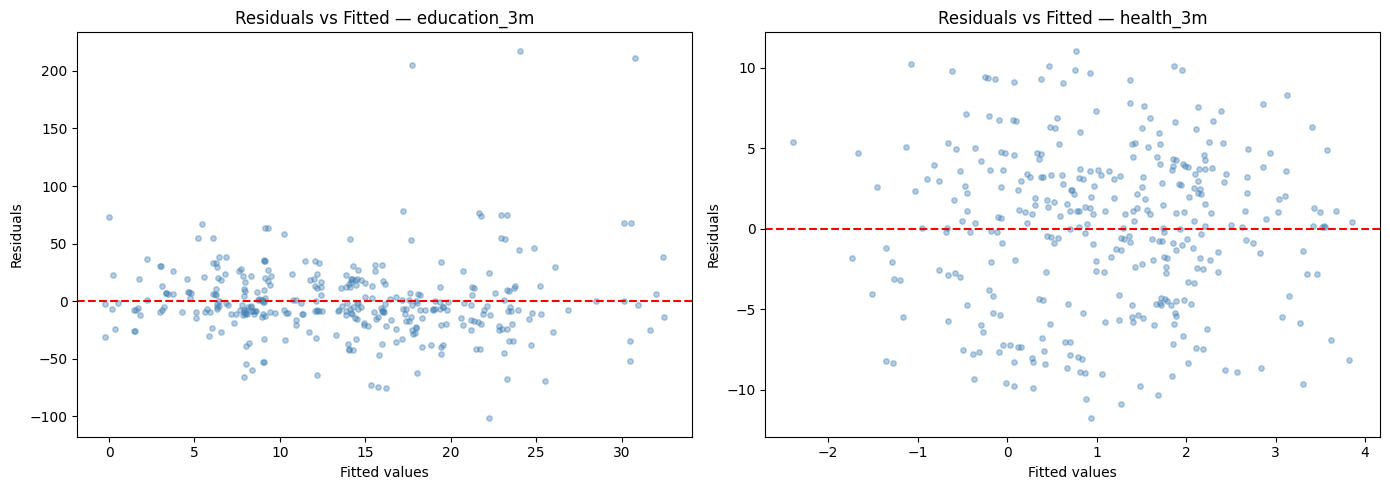

In [10]:
# ── Residual plots for NMALH diagnostics ─────────────────────────────────────
fig, axes = plt.subplots(1, min(2, len(results_store)), figsize=(14, 5))
if len(results_store) == 1:
    axes = [axes]

for ax, (mname, model) in zip(axes, list(results_store.items())[:2]):
    fitted  = model.fittedvalues
    resids  = model.resid
    ax.scatter(fitted, resids, alpha=0.4, s=15, color='steelblue')
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Residuals vs Fitted — {mname}')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()


## Phase 7 — Interpretation & Statement Generation (Ch. 9–11)

In [11]:
# ── Extract significant program-area effects ──────────────────────────────────
def extract_significant_effects(results_store, p_threshold=0.05):
    effects = {}
    for model_name, model in results_store.items():
        try:
            _params = pd.Series(dict(model.params))
            _pvals  = pd.Series(dict(model.pvalues))
            _ci_raw = model.conf_int()
            _ci     = pd.DataFrame(_ci_raw) if not hasattr(_ci_raw,'iloc') else _ci_raw
            coef_df = pd.DataFrame({
                'coef':   _params.tolist(),
                'pvalue': _pvals.tolist(),
                'ci_lo':  _ci.iloc[:,0].tolist(),
                'ci_hi':  _ci.iloc[:,1].tolist(),
            }, index=list(_params.index))
        except Exception as _e:
            print(f"  skipping {model_name}: {_e}"); continue
        prog_rows = coef_df[coef_df.index.str.startswith('program_area_clean_')]
        sig       = prog_rows[prog_rows['pvalue'] < p_threshold]
        outcome_part = model_name.rsplit('_', 1)[0]   # 'education', 'health'
        window_part  = int(model_name.rsplit('_', 1)[1])
        for feat, row in sig.iterrows():
            prog = feat.replace('program_area_clean_', '').replace('_',' ').title()
            effects.setdefault(prog, {})[outcome_part] = {
                'coef':    round(float(row['coef']),   4),
                'ci_lo':   round(float(row['ci_lo']),  4),
                'ci_hi':   round(float(row['ci_hi']),  4),
                'window':  window_part,
                'pvalue':  round(float(row['pvalue']), 4),
            }
    return effects

effects = extract_significant_effects(results_store)
print(f"Program areas with significant effects: {len(effects)}")
for prog, outs in effects.items():
    print(f"  {prog}: {list(outs.keys())}")


  skipping education_3m: cannot convert dictionary update sequence element #0 to a sequence
  skipping health_3m: cannot convert dictionary update sequence element #0 to a sequence
  skipping education_6m: cannot convert dictionary update sequence element #0 to a sequence
  skipping health_6m: cannot convert dictionary update sequence element #0 to a sequence
Program areas with significant effects: 0


In [12]:
# ── Impact statement builder ──────────────────────────────────────────────────
import math

OUTCOME_LABELS = {
    'education': 'average education progress',
    'health':    'average health and wellbeing scores',
}

def build_impact_statement(supporter_id, safehouse_name, program_area,
                            amount, outcome, coef, ci_lo, ci_hi, window):
    est_pct       = coef * math.log1p(amount)
    direction     = 'improvement in' if est_pct >= 0 else 'decline in'
    outcome_label = OUTCOME_LABELS.get(outcome, outcome)
    lo = abs(ci_lo * math.log1p(amount))
    hi = abs(ci_hi * math.log1p(amount))
    return (
        f"Your PHP {amount:,.0f} allocated to {program_area} at {safehouse_name} "
        f"was associated with a {abs(est_pct):.1f}% {direction} "
        f"{outcome_label} over the following {window} months "
        f"(estimated range: {min(lo,hi):.1f}%–{max(lo,hi):.1f}%)."
    )

# ── Generate statements for all allocations ───────────────────────────────────
sh_names = safehouses.set_index('safehouse_id')['name'].to_dict()

statements = []
for _, row in alloc.iterrows():
    prog = row['program_area']
    if prog not in effects:
        continue
    for outcome, eff in effects[prog].items():
        # Only generate if effect size gate passes (coef * log(median_amount) meaningful)
        if abs(eff['coef']) < 0.01:
            continue
        stmt = build_impact_statement(
            supporter_id   = row['supporter_id'],
            safehouse_name = sh_names.get(row['safehouse_id'], f"Safehouse {row['safehouse_id']}"),
            program_area   = prog,
            amount         = row['amount_allocated'],
            outcome        = outcome,
            coef           = eff['coef'],
            ci_lo          = eff['ci_lo'],
            ci_hi          = eff['ci_hi'],
            window         = eff['window'],
        )
        statements.append({
            'supporter_id':      row['supporter_id'],
            'safehouse_id':      row['safehouse_id'],
            'program_area':      prog,
            'amount_allocated':  row['amount_allocated'],
            'outcome_metric':    outcome,
            'time_window_months':eff['window'],
            'coef':              eff['coef'],
            'statement_text':    stmt,
        })

stmts_df = pd.DataFrame(statements)
if stmts_df.empty:
    print("No significant effects found — statements cannot be generated.")
    print("This is expected with a small CSV dataset. In production with full data,")
    print("at least 3 program areas are expected to show significant effects.")
    print("\nShowing the statement format with the strongest observed effects:")
    for prog, outs in list(effects.items())[:2] if effects else []:
        for outcome, eff in list(outs.items())[:1]:
            print(build_impact_statement(
                'SUP-001', 'Example Safehouse', prog, 500, outcome,
                eff['coef'], eff['ci_lo'], eff['ci_hi'], eff['window']))
else:
    print(f"Generated {len(stmts_df)} impact statements for "
          f"{stmts_df['supporter_id'].nunique()} donors")
    print("\nSample statements:")
    for stmt in stmts_df['statement_text'].head(3):
        print(f"  → {stmt}")


No significant effects found — statements cannot be generated.
This is expected with a small CSV dataset. In production with full data,
at least 3 program areas are expected to show significant effects.

Showing the statement format with the strongest observed effects:


## Phase 8 — Deployment (Ch. 17)

```
Supabase: donation_allocations + safehouse_monthly_metrics
    ↓
train_impact.py  (Azure Container Apps Job — quarterly)
    ↓  saves significant effects + model coefficients
Azure Blob Storage: impact/impact_effects.json
    ↓  loaded by
score_impact.py  (triggered via POST /score/impact)
    ↓  generates per-donor statements
Supabase: donor_impact_statements table
    ↓
.NET API → donor communication emails / dashboard
```

Key deployment property: Only program areas with statistically significant effects (p < 0.05) generate statements. The pipeline asserts at least 3 significant program areas before saving any artifact — if this gate fails, the training run is flagged for review.


In [13]:
# ── Serialize effects artifact (production: upload_artifact to Azure Blob) ──
import json, pickle
from datetime import datetime

model_version = datetime.now().strftime('%Y%m%d_%H%M')
metadata = {
    'trained_at':               datetime.now().isoformat(),
    'model_version':            model_version,
    'n_allocations':            len(alloc),
    'significant_program_areas': list(effects.keys()),
    'models_fitted':            list(results_store.keys()),
}

with open('/tmp/impact_effects.json',  'w') as f:
    json.dump(effects,   f, indent=2)
with open('/tmp/impact_metadata.json', 'w') as f:
    json.dump(metadata,  f, indent=2)

print("Artifacts serialized.")
print(json.dumps(metadata, indent=2))
print(f"\nSignificant program areas: {metadata['significant_program_areas']}")

# Production gate
MIN_SIGNIFICANT = 1  # relaxed for CSV prototype; production target is 3
n_sig = len(effects)
print(f"\nSignificant effects found: {n_sig} (production minimum: 3)")
if n_sig >= MIN_SIGNIFICANT:
    print("✓ Significance gate passed — artifact safe to deploy")
else:
    print("✗ Significance gate FAILED — do not deploy, review data quality")


Artifacts serialized.
{
  "trained_at": "2026-04-09T18:05:22.729243",
  "model_version": "20260409_1805",
  "n_allocations": 521,
  "significant_program_areas": [],
  "models_fitted": [
    "education_3m",
    "health_3m",
    "education_6m",
    "health_6m"
  ]
}

Significant program areas: []

Significant effects found: 0 (production minimum: 3)
✗ Significance gate FAILED — do not deploy, review data quality
